# Bearing Fault Diagnosis - 1D Convolutional Autoencoder

In [1]:
import os, glob, re, warnings
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.decomposition import PCA

In [3]:
os.environ["PYTHONHASHSEED"] = str(42)
np.random.seed(42)
tf.random.set_seed(42)

## Dataset

Build dataframe

In [4]:
prefix_label = {"K0": 0, "KA": 1, "KI": 2, "KB": 3}

def build_dataset(root):
  records = []
  bearing_dirs = sorted(
      d for d in glob.glob(os.path.join(root, "*"))
      if os.path.isdir(d)
  )
  print(f"{len(bearing_dirs)} Bearing folders found")

  for bearing_dir in bearing_dirs:
    folder_name = os.path.basename(bearing_dir)
    match = re.match(r"^(K[0A-Z0])", folder_name)
    label = prefix_label.get(match.group(1))

    if match is None or label is None:
      print(f"Invalid folder name: {folder_name}")
      continue
    
    for fpath in sorted(glob.glob(os.path.join(bearing_dir, "*.mat"))):
      records.append({"path": fpath, "label": label, "folder": folder_name})
  df = pd.DataFrame(records)
  print(f"Total Number of files: {len(df)}")
  print("Files per class: ", df.groupby("label").size().to_dict())
  return df

dataset = build_dataset(DATASET_ROOT)
files_tmp, files_test = train_test_split(dataset, test_size = 0.15, stratify = dataset["label"], random_state = 42)
files_train, files_val = train_test_split(files_tmp, test_size = 0.15 / 0.85, stratify = files_tmp["label"], random_state = 42)
print(f"Train files: {len(files_train)}")
print(f"Validation files: {len(files_val)}")
print(f"Test files: {len(files_test)}")

32 Bearing folders found
Total Number of files: 2560
Files per class:  {0: 480, 1: 960, 2: 880, 3: 240}
Train files: 1792
Validation files: 384
Test files: 384


## Data Processing

Windowing and feature extraction

In [5]:
label_names = {0: "Healthy (K0)", 1: "Outer Fault (KA)", 2: "Inner Fault (KI)", 3: "Other Fault (KB)"}

def extract_vibrations(mat_path):
  try:
    mat = sio.loadmat(mat_path)
    key = [k for k in mat if not k.startswith("_")][0]
    root = mat[key][0, 0]
    data = root["Y"][0, 0]["Data"]
    return data.flatten().astype(np.float32)
  except Exception as exc:
    print(f"{exc}")
    return None

def sliding_window(signal, window = 1024, hop = 512):
  starts = range(0, len(signal) - window + 1, hop)
  return np.stack([signal[s:s + window] for s in starts])

def files_to_windows(file, split_name = ""):
  X_list, y_list = [], []
  for _, row in file.iterrows():
    signal = extract_vibrations(row["path"])

    if signal is None or len(signal) < 1024:
      continue

    windows = sliding_window(signal)
    X_list.append(windows)
    y_list.append(np.full(len(windows), row["label"], dtype = np.int32))
  X = np.concatenate(X_list)
  y = np.concatenate(y_list)
  dist = {label_names[k]: int((y == k).sum()) for k in range(4) if (y == k).any()}
  print(f"{split_name:6s}: {len(X):>8,} windows | {dist}")
  return X, y

def normalize_window(X):
    mean = X.mean(axis = 1, keepdims = True)
    std = X.std(axis = 1, keepdims = True) + 1e-8
    return (X - mean) / std

File-level splitting, normalization and class weights

In [6]:
X_train, y_train = files_to_windows(files_train, "Train")
X_val, y_val = files_to_windows(files_val, "Validation")
X_test, y_test = files_to_windows(files_test, "Test")

X_train = normalize_window(X_train)
X_val = normalize_window(X_val)
X_test = normalize_window(X_test)

X_healthy_train = X_train[y_train == 0]
X_healthy_val = X_val[y_val == 0]
print(f"Healthy train: {len(X_healthy_train)}")
print(f"Healthy val: {len(X_healthy_val):,}")

label_names = {0: "Healthy (K0)", 1: "Outer Fault (KA)", 2: "Inner Fault (KI)", 3: "Other Fault (KB)"}
classes = np.unique(y_train)
raw_weights = compute_class_weight("balanced", classes = classes, y = y_train)
class_weight = dict(zip(classes.tolist(), raw_weights.tolist()))
print("Class weights: ", {label_names[k]: f"{v:.3f}" for k, v in class_weight.items()})

Train :   53,767 windows | {'Healthy (K0)': 10080, 'Outer Fault (KA)': 20160, 'Inner Fault (KI)': 18487, 'Other Fault (KB)': 5040}
Expecting matrix here
Validation:   11,490 windows | {'Healthy (K0)': 2160, 'Outer Fault (KA)': 4290, 'Inner Fault (KI)': 3960, 'Other Fault (KB)': 1080}
Test  :   11,520 windows | {'Healthy (K0)': 2160, 'Outer Fault (KA)': 4320, 'Inner Fault (KI)': 3960, 'Other Fault (KB)': 1080}
Healthy train: 10080
Healthy val: 2,160
Class weights:  {'Healthy (K0)': '1.334', 'Outer Fault (KA)': '0.667', 'Inner Fault (KI)': '0.727', 'Other Fault (KB)': '2.667'}


In [7]:
print(f"Train shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (53767, 1024)
Val shape: (11490, 1024)
Test shape: (11520, 1024)


## Model Training

1D-Convolutional Autoencoder

In [8]:
def build_autoencoder(input_dim = 1024, latent_dim = 32):

  # Encoder
  input = keras.Input(shape = (input_dim, 1), name = "encoder_input")
  x = layers.Conv1D(32, 7, strides = 2, padding = "same", activation = "relu", name = "conv_block1")(input)
  x = layers.BatchNormalization(name = "bn1")(x)
  x = layers.Conv1D(64, 5, strides = 2, padding = "same", activation = "relu", name = "conv_block2")(x)
  x = layers.BatchNormalization(name = "bn2")(x)
  x = layers.Conv1D(128, 3, strides = 2, padding = "same", activation = "relu", name = "conv_block3")(x)
  x = layers.BatchNormalization(name = "bn3")(x)

  before_flatten = x.shape[1:]
  x = layers.Flatten()(x)
  latent = layers.Dense(latent_dim, name = "latent")(x)
  encoder = Model(input, latent, name = "encoder")

  # Decoder
  latent_input = layers.Input(shape = (latent_dim,), name = "decoder_input")
  flat_dim = int(np.prod(before_flatten))
  x = layers.Dense(flat_dim, activation = "relu")(latent_input)
  x = layers.Reshape(before_flatten)(x)
  x = layers.Conv1DTranspose(128, 2, strides = 2, padding = "same", activation = "relu")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv1DTranspose(64, 5, strides = 2, padding = "same", activation = "relu")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv1DTranspose(32, 7, strides = 2, padding = "same", activation = "relu")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv1D(1, 3, padding = "same", activation = "linear", name = "decoder_output")(x)

  if x.shape[1] > input_dim:
    x = layers.Cropping1D((0, x.shape[1] - input_dim))(x)
  decoder = Model(latent_input, x, name = "decoder")

  # Autoencoder
  ae_input = keras.Input(shape = (input_dim, 1), name = "ae_input")
  ae_output = decoder(encoder(ae_input))
  autoencoder = Model(ae_input, ae_output, name = "autoencoder")
  return autoencoder, encoder, decoder

autoencoder, encoder, decoder = build_autoencoder()
autoencoder.compile(optimizer = keras.optimizers.Adam(1e-3), loss = "mse")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       560,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 1024, 1)        │       629,953 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,190,433 (4.54 MB)

 Trainable params: 1,189,537 (4.54 MB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
X_healthy_train = X_healthy_train[..., np.newaxis]
X_healthy_val = X_healthy_val[..., np.newaxis]

callbacks_ae = [
    callbacks.EarlyStopping(monitor = "val_loss", patience = 8, restore_best_weights = True, verbose = 1),
    callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = 4, min_lr = 1e-6, verbose = 1)
]

history_ae = autoencoder.fit(
    X_healthy_train, X_healthy_train,
    validation_data = (X_healthy_val, X_healthy_val),
    epochs = 60,
    batch_size = 64,
    callbacks = callbacks_ae,
    verbose = 1
)

Epoch 1/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 0.2347 - val_loss: 0.5363 - learning_rate: 0.0010
Epoch 2/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - loss: 0.1489 - val_loss: 0.2090 - learning_rate: 0.0010
Epoch 3/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.1381 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 4/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - loss: 0.1332 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 5/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - loss: 0.1307 - val_loss: 0.1389 - learning_rate: 0.0010
Epoch 6/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.1293 - val_loss: 0.1355 - learning_rate: 0.0010
Epoch 7/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 0.1284 - val_loss: 0.1339 - learning_rate: 0.0010
Epoch 8/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - loss: 0.1277 - val_loss: 0.1327 - learning_rate: 0.0010
Epoch 9/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.1270 - val_loss: 0.1321 - learn

Predict for anomaly detection

In [10]:
X_test_ae = X_test[..., np.newaxis] 
X_test_pred = autoencoder.predict(X_test_ae)

mpe = np.mean(
    np.abs(X_test_ae.squeeze() - X_test_pred.squeeze()) / (np.abs(X_test_ae.squeeze()) + 1e-8),
    axis=1
)

X_val_healthy_pred = autoencoder.predict(X_healthy_val)
mpe_val_healthy = np.mean(
    np.abs(X_healthy_val.squeeze() - X_val_healthy_pred.squeeze()) / (np.abs(X_healthy_val.squeeze()) + 1e-8),
    axis=1
)
threshold = np.percentile(mpe_val_healthy, 80)
print(f"Anomaly Threshold: {threshold:.6f}")

360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Anomaly Threshold: 0.993710


Training vs Validation Curve (Loss) - Anomaly Detection

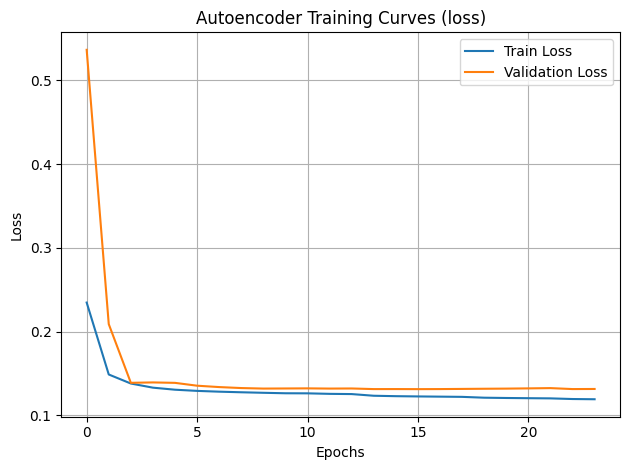

In [37]:
plt.figure()
plt.plot(history_ae.history["loss"], label = "Train Loss")
plt.plot(history_ae.history["val_loss"], label = "Validation Loss")
plt.title("Autoencoder Training Curves (loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
y_pred_binary = (mpe > threshold).astype(int)
y_true_binary = (y_test > 0).astype(int)
print(classification_report(y_true_binary, y_pred_binary, target_names = ["Healthy", "Faulty"]))

              precision    recall  f1-score   support

     Healthy       0.26      0.80      0.39      2160
      Faulty       0.91      0.46      0.61      9360

    accuracy                           0.53     11520
   macro avg       0.58      0.63      0.50     11520
weighted avg       0.79      0.53      0.57     11520



Confusion Matrix - Anomaly Detection

In [12]:
cm_binary = confusion_matrix(y_true_binary, y_pred_binary)
print("Anomaly Detection - Confusion Matrix")
print(f"True Negatives (Correct healthy): {cm_binary[0,0]}")
print(f"False Positives (False alarms): {cm_binary[0,1]}")
print(f"False Negatives (Missed faults): {cm_binary[1,0]}")
print(f"True Positives (Detected faults): {cm_binary[1,1]}")

Anomaly Detection - Confusion Matrix
True Negatives (Correct healthy): 1727
False Positives (False alarms): 433
False Negatives (Missed faults): 5013
True Positives (Detected faults): 4347


### Phase 1: Frozen encoder + Classifier 

Classifier

In [15]:
def build_classifier(encoder_model = Model, n_classes = 4, freeze_encoder = True):
    encoder_model.trainable = not freeze_encoder
    input = keras.Input(shape = (1024, 1), name = "classifier_input")
    latent = encoder_model(input)
    x = layers.Dense(64, activation = "relu", kernel_regularizer = regularizers.l2(1e-4), name = "head_dense1")(latent)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation = "relu", kernel_regularizer = regularizers.l2(1e-4), name = "head_dense2")(x)
    output = layers.Dense(n_classes, activation = "softmax", name = "classifier_output")(x)
    return Model(input, output, name = "ae_classifier")

classifier = build_classifier(encoder, freeze_encoder = True)
classifier.compile(optimizer = keras.optimizers.Adam(1e-3), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
classifier.summary()

Model: "ae_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       560,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense1 (Dense)             │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_output (Dense)       │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,804 (2.15 MB)

 Trainable params: 4,324 (16.89 KB)

 Non-trainable params: 560,480 (2.14 MB)

In [16]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(53767, 1024)
(11490, 1024)
(11520, 1024)


In [17]:
X_train_cls = X_train[..., np.newaxis]
X_val_cls = X_val[..., np.newaxis]

callbacks_cls1 = [
    callbacks.EarlyStopping(monitor = "val_loss", patience = 10, restore_best_weights = True, verbose = 1),
    callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience= 5, min_lr = 1e-6, verbose = 1)
] 

history_cls1 = classifier.fit(
    X_train_cls, y_train,
    validation_data = (X_val_cls, y_val),
    epochs = 60, 
    batch_size = 64, 
    callbacks = callbacks_cls1,
    class_weight = class_weight,
    verbose = 1
)

gap1 = history_cls1.history["accuracy"][-1] - history_cls1.history["val_accuracy"][-1]
print(f"Training/Validation accuracy gap: {gap1:+.4f}")


Epoch 1/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3343 - loss: 1.7223 - val_accuracy: 0.4447 - val_loss: 1.1649 - learning_rate: 0.0010
Epoch 2/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4072 - loss: 1.1559 - val_accuracy: 0.4841 - val_loss: 1.0854 - learning_rate: 0.0010
Epoch 3/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4579 - loss: 1.0508 - val_accuracy: 0.5471 - val_loss: 0.9908 - learning_rate: 0.0010
Epoch 4/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4909 - loss: 0.9912 - val_accuracy: 0.5679 - val_loss: 0.9484 - learning_rate: 0.0010
Epoch 5/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5167 - loss: 0.9451 - val_accuracy: 0.5822 - val_loss: 0.9172 - learning_rate: 0.0010
Epoch 6/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5343 - loss: 0.9135 - val_accuracy: 0.5998 - val_loss: 0.8856 - learning_rate: 0.0010
Epoch 7/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5405 - loss: 0.8958 - 

### Phase 2: Unfreezed encoder + pre-trained classifier

In [18]:
encoder_layer = classifier.get_layer("encoder")
encoder_layer.trainable = True
for layer in encoder.layers:
    layer.trainable = False

unfreeze_layers = ["conv_block3", "bn3", "latent"]
for layer in encoder_layer.layers:
    if layer.name in unfreeze_layers:
        layer.trainable = True
for layer in encoder_layer.layers:
    status = "trainable" if layer.trainable else "frozen"
    print(f"- {layer.name} -> {status}")

- encoder_input -> frozen
- conv_block1 -> frozen
- bn1 -> frozen
- conv_block2 -> frozen
- bn2 -> frozen
- conv_block3 -> trainable
- bn3 -> trainable
- flatten -> frozen
- latent -> trainable


In [19]:
trainable_params = sum(np.prod(v.shape) for v in classifier.trainable_variables)
total_params = sum(np.prod(v.shape) for v in classifier.variables)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Trainable parameters: 553,604 / 564,806


In [20]:
classifier.compile(
    optimizer = keras.optimizers.Adam(1e-3 / 20),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

callbacks_cls2 = [
    callbacks.EarlyStopping(monitor = "val_loss", patience = 12, restore_best_weights = True, verbose = 1),
    callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience= 6, min_lr = 1e-7, verbose = 1)
] 

history_cls2 = classifier.fit(
    X_train_cls, y_train,
    validation_data = (X_val_cls, y_val),
    epochs = 60,
    batch_size = 64,
    callbacks = callbacks_cls2,
    class_weight = class_weight,
    verbose = 1
)

gap2 = history_cls2.history["accuracy"][-1] - history_cls2.history["val_accuracy"][-1]
print(f"Training/Validation accuracy gap: {gap2:+.4f}")

Epoch 1/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.6564 - loss: 0.6812 - val_accuracy: 0.7144 - val_loss: 0.6608 - learning_rate: 5.0000e-05
Epoch 2/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6800 - loss: 0.6356 - val_accuracy: 0.7379 - val_loss: 0.6264 - learning_rate: 5.0000e-05
Epoch 3/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6975 - loss: 0.6048 - val_accuracy: 0.7405 - val_loss: 0.6183 - learning_rate: 5.0000e-05
Epoch 4/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7032 - loss: 0.5832 - val_accuracy: 0.7632 - val_loss: 0.5852 - learning_rate: 5.0000e-05
Epoch 5/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7164 - loss: 0.5652 - val_accuracy: 0.7581 - val_loss: 0.5746 - learning_rate: 5.0000e-05
Epoch 6/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7241 - loss: 0.5466 - val_accuracy: 0.7742 - val_loss: 0.5560 - learning_rate: 5.0000e-05
Epoch 7/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/ste

## Evaluation

Predict for multi-classification

In [21]:
label_names = {0: "Healthy (K0)", 1: "Outer Fault (KA)", 2: "Inner Fault (KI)", 3: "Other Fault (KB)"}
label_list = [label_names[k] for k in sorted(label_names)]
y_prob = classifier.predict(X_test, batch_size = 256, verbose = 0)
y_pred = np.argmax(y_prob, axis = 1)
print(classification_report(y_test, y_pred, target_names = label_list))

                  precision    recall  f1-score   support

    Healthy (K0)       0.80      0.88      0.84      2160
Outer Fault (KA)       0.85      0.82      0.84      4320
Inner Fault (KI)       0.89      0.85      0.87      3960
Other Fault (KB)       0.88      0.97      0.92      1080

        accuracy                           0.86     11520
       macro avg       0.86      0.88      0.87     11520
    weighted avg       0.86      0.86      0.86     11520



Training vs Validation Curves - Phase 1 and Phase 2 (Accuracy and Loss)

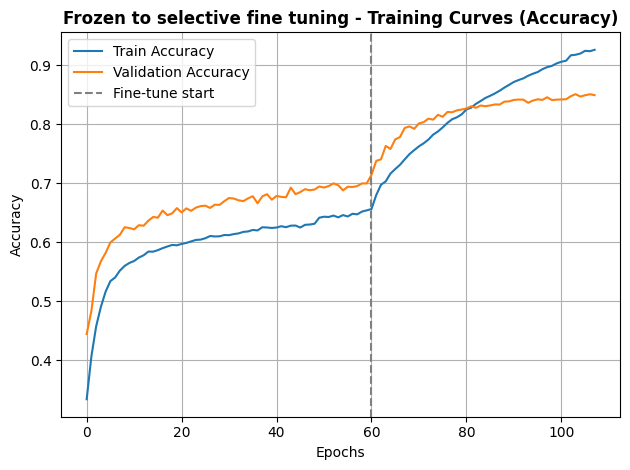

In [38]:
combined_acc = (history_cls1.history["accuracy"] + history_cls2.history["accuracy"])
combined_val_acc = (history_cls1.history["val_accuracy"] + history_cls2.history["val_accuracy"])
sp = len(history_cls1.history["accuracy"])
plt.figure()
plt.plot(combined_acc, label = "Train Accuracy")
plt.plot(combined_val_acc, label = "Validation Accuracy")
plt.axvline(sp, ls = "--", color = "grey", label = "Fine-tune start")
plt.title("Frozen to selective fine tuning - Training Curves (Accuracy)", fontweight = "bold")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

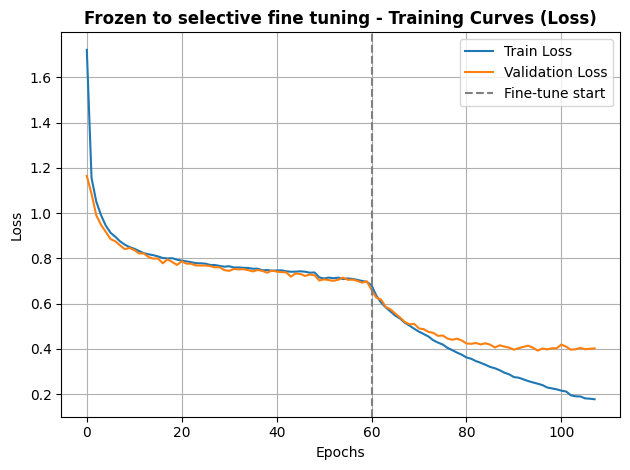

In [29]:
combined_loss = (history_cls1.history["loss"] + history_cls2.history["loss"])
combined_val_loss = (history_cls1.history["val_loss"] + history_cls2.history["val_loss"])
sp = len(history_cls1.history["loss"])
plt.figure()
plt.plot(combined_loss, label = "Train Loss")
plt.plot(combined_val_loss, label = "Validation Loss")
plt.axvline(sp, ls = "--", color = "grey", label = "Fine-tune start")
plt.title("Frozen to selective fine tuning - Training Curves (Loss)", fontweight = "bold")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [30]:
print(f"Train/val accuracy gap - phase 1 : {gap1}")
print(f"Train/val accuracy gap - phase 2: {gap2}")
print(f"Improvement gap: {gap1 - gap2}")

Train/val accuracy gap - phase 1 : -0.04565739631652832
Train/val accuracy gap - phase 2: 0.07674789428710938
Improvement gap: -0.1224052906036377


Confusion Matrix - Multi-classification

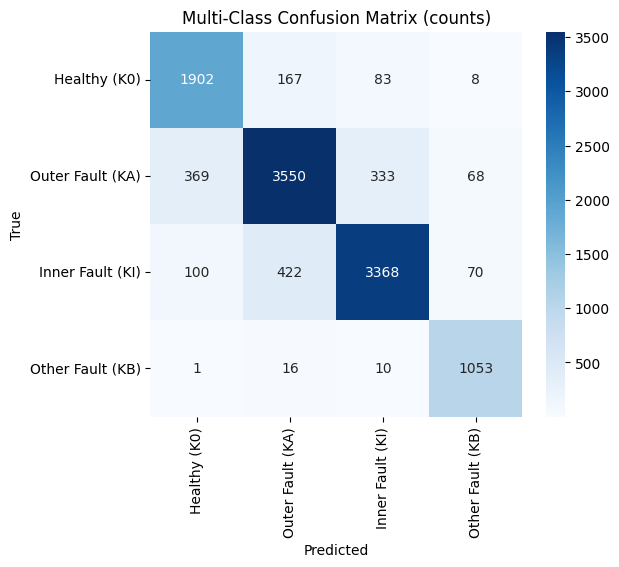

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, cmap = "Blues", fmt = "d", xticklabels = label_list, yticklabels = label_list)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Multi-Class Confusion Matrix (counts)")
plt.show()

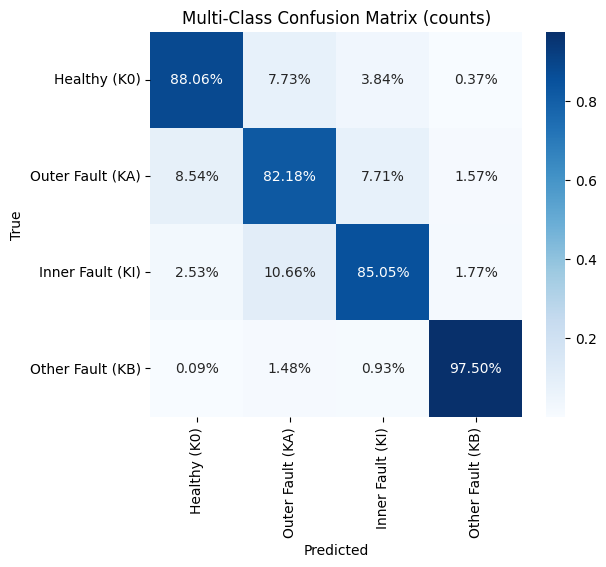

In [35]:
cm_norm = cm.astype(float) / cm.sum(axis = 1, keepdims = True)
plt.figure(figsize = (6, 5))
sns.heatmap(cm_norm, annot = True, cmap = "Blues", fmt = ".2%", xticklabels = label_list, yticklabels = label_list)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Multi-Class Confusion Matrix (counts)")
plt.show()

In [ ]:
y_pred_binary = (mpe > threshold).astype(int)
y_true_binary = (y_test > 0).astype(int)
print(classification_report(y_true_binary, y_pred_binary, target_names = ["Healthy", "Faulty"]))

              precision    recall  f1-score   support

     Healthy       0.26      0.80      0.39      2160
      Faulty       0.91      0.46      0.61      9360

    accuracy                           0.53     11520
   macro avg       0.58      0.63      0.50     11520
weighted avg       0.79      0.53      0.57     11520



ROC Curves

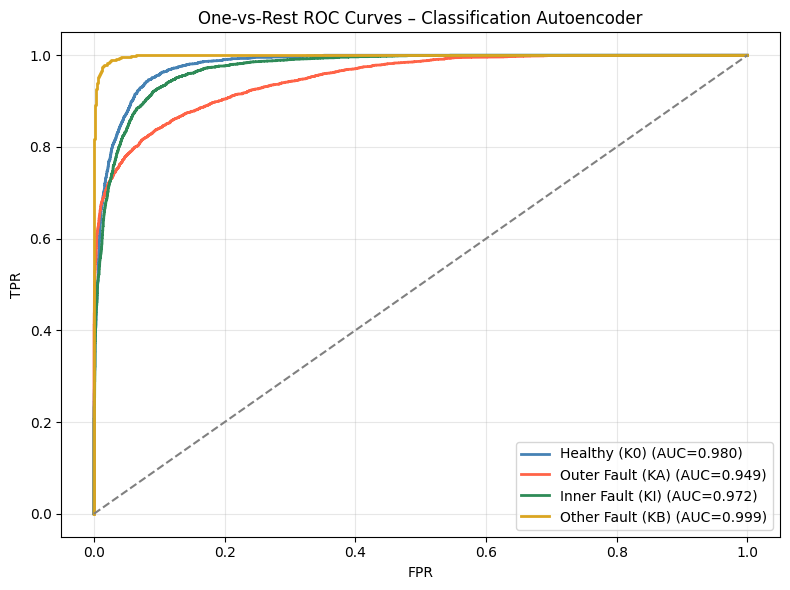

In [34]:
y_bin  = label_binarize(y_test, classes=[0, 1, 2, 3])
colors = ['steelblue', 'tomato', 'seagreen', 'goldenrod']

plt.figure(figsize=(8, 6))
for i, (name, col) in enumerate(zip(label_list, colors)):
    fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i, lw=2, color=col, label=f'{name} (AUC={auc_i:.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('One-vs-Rest ROC Curves – Classification Autoencoder')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
